# My research question: 
## Which factors, including salary, job title, work type, and geographical location, have the greatest impact on the number of job views?

In [2]:
# Importing Pandas, Matplot and Numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

# Import calendar to get names of months
import calendar

df_basic_info = pd.read_csv(
    'C:/Users/wensa/1. spPDAS/DAAAFT1B07-2518367-GohWenSan/CA1 Dataset/CA1 Dataset/postings1.csv',
    low_memory=False
)

df_job_desc = pd.read_csv(
    'C:/Users/wensa/1. spPDAS/DAAAFT1B07-2518367-GohWenSan/CA1 Dataset/CA1 Dataset/postings2.csv',
    low_memory=False
)

df_salary_breakdown = pd.read_csv(
    'C:/Users/wensa/1. spPDAS/DAAAFT1B07-2518367-GohWenSan/CA1 Dataset/CA1 Dataset/postings3.csv',
    low_memory=False
)

df_app_process = pd.read_csv(
    'C:/Users/wensa/1. spPDAS/DAAAFT1B07-2518367-GohWenSan/CA1 Dataset/CA1 Dataset/postings4.csv',
    low_memory=False
)

df_dupe = pd.read_excel(
    'C:/Users/wensa/1. spPDAS/DAAAFT1B07-2518367-GohWenSan/CA1 Dataset/CA1 Dataset/postings5.xlsx'
)
#shapes - row and columns
print("postings1:", df_basic_info.shape)
print("postings2:", df_job_desc.shape)
print("postings3:", df_salary_breakdown.shape)
print("postings4:", df_app_process.shape)
print("postings5:", df_dupe.shape)

postings1: (123849, 21)
postings2: (123849, 3)
postings3: (123849, 7)
postings4: (123849, 18)
postings5: (123849, 5)


##### BASIC DATA ( COLUMNS AND ROWS )

postings1:The dataset has 123,849 rows (job postings) and 21 columns (features)

postings2: 123,849 rows 3 columns.This means postings2 aligns row by row with postings1 (good for merging)

postings3: 123,849 rows 7 columns

postings4: 123,849 rows 18 columns

postings5: 123,849 rows 5 columns

# Exploratoy Data Analysis (EDA)

before going further into the data i will first explain the data files 

##### 1) First File: job_id, company_name, title
 provides foundational job posting information such as job titles, company names, locations, and work types. These variables directly support the research question because they allow me to see
* How job title affects job views
* How geographical location (city/country) influences popularity
* How work type (full-time, part-time, contract, remote) impacts job seeker interest
This file provides the core structure of each job posting, which is necessary for comparing how different job characteristics relate to the number of job views.
##### 2) Second File: job_id, description, max_salary
Purpose: Adds job descriptions and maximum salary information.
Use: Useful for salary analysis (e.g., comparing max salary across jobs or locations) and text-based analysis of job descriptions.
##### 3) Third File: job_id, pay_period, location, company_id, views, med_salary, min_salary
 contains salary-related information such as minimum salary, maximum salary, estimated pay, or salary currency. These details are essential for analysing:
* Whether higher salary ranges attract more job views
* How salary differences across cities or job types influence engagement
* Which roles get more attention due to better compensation
This file helps address the part of the research question related to salary’s impact on job views.
Key Note: The company_id can be linked to the company_name for additional insights.
##### 4) Fourth File: Comprehensive Job Metadata
 includes job view counts, posting performance metrics, or timestamps, which are crucial because number of job views is the dependent variable. It allows direct measurement of what factors increase or decrease engagement.Extra metrics (e.g., saves, applies) help validate user interest
Without this file, you would not be able to measure the impact of the predictors.
##### 5) Fifth File: Auxiliary/Redundant Data
Columns: Includes duplicate information (job_id, company_name, title) and unnecessary columns (easter egg, unimportant column). same as file1
Purpose: May not be good for analysis but can act as a secondary validation dataset.
Action: Remove unnecessary columns and deduplicate against the first file.

In [3]:
# understanding data through missing values, rows ,cols,check for duplicates

def get_info(df,filename):
    print(70*"*", f"\n Information about {filename}", '\n' + "*"*70 + '\n')
    print(f'There are {df.shape[0]} rows and {df.shape[1]} columns in this dataset\n')
    print(f'The number of duplicates in this dataframe is {df.duplicated().sum()}\n')
    print(f'The names of the columns are:')
   
    for col in df.columns:
        dtype = df[col].dtype
        na_values = df[col].isna().sum()
        unique_values = df[col].nunique()
        is_numeric = pd.api.types.is_numeric_dtype(df[col])
        print(f'- {col} ({dtype}), na values: {na_values}, unique values: {unique_values}, numeric values: ({is_numeric})')

In [4]:
#FILE 1
get_info(df_basic_info, 'job basic info')

********************************************************************** 
 Information about job basic info 
**********************************************************************

There are 123849 rows and 21 columns in this dataset

The number of duplicates in this dataframe is 0

The names of the columns are:
- job_id (int64), na values: 0, unique values: 123849, numeric values: (True)
- company_name (object), na values: 1719, unique values: 24428, numeric values: (False)
- title (object), na values: 0, unique values: 72521, numeric values: (False)
- Easter Egg (object), na values: 115041, unique values: 1, numeric values: (False)
- Unimportant Column (float64), na values: 119672, unique values: 1, numeric values: (True)
- Easter Egg.1 (object), na values: 115041, unique values: 1, numeric values: (False)
- Unimportant Column.1 (float64), na values: 119672, unique values: 1, numeric values: (True)
- Easter Egg.2 (object), na values: 115041, unique values: 1, numeric values: (False)
- 

In [5]:
#FILE 2
get_info(df_job_desc, 'job des and max')

********************************************************************** 
 Information about job des and max 
**********************************************************************

There are 123849 rows and 3 columns in this dataset

The number of duplicates in this dataframe is 0

The names of the columns are:
- job_id (int64), na values: 0, unique values: 123849, numeric values: (True)
- description (object), na values: 7, unique values: 107826, numeric values: (False)
- max_salary (float64), na values: 94056, unique values: 5321, numeric values: (True)


In [6]:
#FILE 3
get_info(df_salary_breakdown, 'salary breakdown')


********************************************************************** 
 Information about salary breakdown 
**********************************************************************

There are 123849 rows and 7 columns in this dataset

The number of duplicates in this dataframe is 0

The names of the columns are:
- job_id (int64), na values: 0, unique values: 123849, numeric values: (True)
- pay_period (object), na values: 87776, unique values: 5, numeric values: (False)
- location (object), na values: 0, unique values: 8526, numeric values: (False)
- company_id (float64), na values: 1717, unique values: 24474, numeric values: (True)
- views (float64), na values: 1689, unique values: 684, numeric values: (True)
- med_salary (float64), na values: 117569, unique values: 1417, numeric values: (True)
- min_salary (float64), na values: 94056, unique values: 4612, numeric values: (True)


In [7]:
#FILE 4
get_info(df_app_process, 'app process')

********************************************************************** 
 Information about app process 
**********************************************************************

There are 123849 rows and 18 columns in this dataset

The number of duplicates in this dataframe is 0

The names of the columns are:
- job_id (int64), na values: 0, unique values: 123849, numeric values: (True)
- formatted_work_type (object), na values: 0, unique values: 7, numeric values: (False)
- applies (float64), na values: 100529, unique values: 274, numeric values: (True)
- original_listed_time (float64), na values: 0, unique values: 206, numeric values: (True)
- remote_allowed (float64), na values: 108603, unique values: 1, numeric values: (True)
- job_posting_url (object), na values: 0, unique values: 123849, numeric values: (False)
- application_url (object), na values: 36665, unique values: 84800, numeric values: (False)
- application_type (object), na values: 0, unique values: 4, numeric values: (Fals

In [8]:
#FILE 5
get_info(df_dupe, 'dupe data')

********************************************************************** 
 Information about dupe data 
**********************************************************************

There are 123849 rows and 5 columns in this dataset

The number of duplicates in this dataframe is 0

The names of the columns are:
- job_id (int64), na values: 0, unique values: 123849, numeric values: (True)
- company_name (object), na values: 1719, unique values: 24428, numeric values: (False)
- title (object), na values: 0, unique values: 72521, numeric values: (False)
- Easter Egg (object), na values: 115041, unique values: 1, numeric values: (False)
- Unimportant Column (float64), na values: 119672, unique values: 1, numeric values: (True)


From the tables above i can tell that:
All of them have no duplicates 
1. The remaining columns (multiple Easter Egg and Unimportant Column fields) all have only one unique value, so they do not add any information and can be safely dropped. This is mainly used to provide the core identifiers and labels (job ID, company, and title) for each posting.
2. All three columns are informative. This file adds textual job descriptions and an important numeric feature, maximum salary, which can be used to study how salary range relates to job views.
3. This file is crucial because it provides the job views (views) and a more detailed salary structure (min/median) as well as location, all of which directly relate to my research question.
4. These variables describe the posting behaviour and job characteristics (work type, remote vs on-site, experience level, skills, etc.). Many of them are potential predictors of job views and applications.
5. The first three columns duplicate information already present in job basic info, while Easter Egg and Unimportant Column have only one unique value each. Overall, this file does not add new information and can be ignored.

# Identifying common data

In [9]:
# File 1
df_basic_info.head()


,job_id,company_name,title,Easter Egg,Unimportant Column,Easter Egg.1,Unimportant Column.1,Easter Egg.2,Unimportant Column.2,Easter Egg.3,...,Easter Egg.4,Unimportant Column.4,Easter Egg.5,Unimportant Column.5,Easter Egg.6,Unimportant Column.6,Easter Egg.7,Unimportant Column.7,Easter Egg.8,Unimportant Column.8
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",...,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0
1,1829192,NaN,Mental Health Therapist/Counselor,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",...,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",...,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",...,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0
4,35982263,NaN,Service Technician,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",...,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0,"In order to score well for this module, you sh...",1.0


In [10]:
# File 2
df_job_desc.head()

,job_id,description,max_salary
0,921716,Job descriptionA leading real estate firm in N...,20.0
1,1829192,"At Aspen Therapy and Wellness , we are committ...",50.0
2,10998357,The National Exemplar is accepting application...,65000.0
3,23221523,Senior Associate Attorney - Elder Law / Trusts...,175000.0
4,35982263,Looking for HVAC service tech with experience ...,80000.0


In [11]:
# File 3
df_salary_breakdown.head()

,job_id,pay_period,location,company_id,views,med_salary,min_salary
0,921716,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0
1,1829192,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0
2,10998357,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0
3,23221523,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0
4,35982263,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0


In [12]:
# File 4
df_app_process.head()

,job_id,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
0,921716,Full-time,2.0,1.713400e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk...,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,Requirements: \n\nWe are seeking a College or ...,1.713400e+12,NaN,0,FULL_TIME,USD,BASE_SALARY
1,1829192,Full-time,NaN,1.712860e+12,NaN,https://www.linkedin.com/jobs/view/1829192/?tr...,NaN,ComplexOnsiteApply,1.715450e+12,NaN,NaN,NaN,1.712860e+12,NaN,0,FULL_TIME,USD,BASE_SALARY
2,10998357,Full-time,NaN,1.713280e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?t...,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - A...,1.713280e+12,NaN,0,FULL_TIME,USD,BASE_SALARY
3,23221523,Full-time,NaN,1.712900e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?t...,NaN,ComplexOnsiteApply,1.715490e+12,NaN,NaN,This position requires a baseline understandin...,1.712900e+12,NaN,0,FULL_TIME,USD,BASE_SALARY
4,35982263,Full-time,NaN,1.713450e+12,NaN,https://www.linkedin.com/jobs/view/35982263/?t...,NaN,ComplexOnsiteApply,1.716040e+12,NaN,NaN,NaN,1.713450e+12,NaN,0,FULL_TIME,USD,BASE_SALARY


In [13]:
# File 5
df_dupe.head()

,job_id,company_name,title,Easter Egg,Unimportant Column
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,"In order to score well for this module, you sh...",1.0
1,1829192,NaN,Mental Health Therapist/Counselor,"In order to score well for this module, you sh...",1.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,"In order to score well for this module, you sh...",1.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,"In order to score well for this module, you sh...",1.0
4,35982263,NaN,Service Technician,"In order to score well for this module, you sh...",1.0


#### Looking at all the datasets above, there was a common column that every dataset had, 'job_id. This will be the column will allow me to merge datasets togther

# Merging datasets

#### Step 1. 
2 main points I had to focus on before I select the columns to merge :
* 1. Low Missing Values: Columns with less than 70% missing values.
* 2. Relevance: Columns relevant to the research question.

Job ID – Serves as the unique identifier for merging all datasets accurately.

Company Name – Used as a reference point when handling missing values or validating job posting information.

Job Title – Important for analysing how different roles attract varying levels of job views.

Location – Essential for evaluating the impact of geographical differences on job views.

Views – The dependent variable (target) for this study, representing the level of engagement each job posting receives.

Salary Information (Median Salary) – Included to assess how salary levels influence job seeker interest.

Work Type – Allows comparison between full-time, part-time, contract, hybrid, and remote jobs to understand their effects on job views.

Experience Level – Helps determine whether seniority requirements affect the popularity of job postings.

Pay Period – Indicates whether salaries are hourly, monthly, or yearly; primarily used for standardisation to ensure salaries are comparable across all postings.

In [14]:
# Copy selected columns from each dataframe
basic_info_subset = df_basic_info[['job_id','company_name','title']].copy()
salary_breakdown_subset = df_salary_breakdown[['job_id', 'location', 'views', 'pay_period','med_salary']].copy()
app_process_subset = df_app_process[['job_id', 'work_type', 'formatted_experience_level']].copy()


# Merge the datasets on 'job_id'
merged_df = basic_info_subset.merge(salary_breakdown_subset, on='job_id', how='left')
merged_df = merged_df.merge(app_process_subset, on='job_id', how='left')


In [15]:
merged_df.head()

,job_id,company_name,title,location,views,pay_period,med_salary,work_type,formatted_experience_level
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,"Princeton, NJ",20.0,HOURLY,NaN,FULL_TIME,NaN
1,1829192,NaN,Mental Health Therapist/Counselor,"Fort Collins, CO",1.0,HOURLY,NaN,FULL_TIME,NaN
2,10998357,The National Exemplar,Assitant Restaurant Manager,"Cincinnati, OH",8.0,YEARLY,NaN,FULL_TIME,NaN
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",16.0,YEARLY,NaN,FULL_TIME,NaN
4,35982263,NaN,Service Technician,"Burlington, IA",3.0,YEARLY,NaN,FULL_TIME,NaN


In [16]:
print(merged_df.head)
print(merged_df.columns)

<bound method NDFrame.head of             job_id                     company_name  \
0           921716            Corcoran Sawyer Smith   
1          1829192                              NaN   
2         10998357           The National Exemplar    
3         23221523           Abrams Fensterman, LLP   
4         35982263                              NaN   
...            ...                              ...   
123844  3906267117                     Lozano Smith   
123845  3906267126                        Pinterest   
123846  3906267131                     EPS Learning   
123847  3906267195  Trelleborg Applied Technologies   
123848  3906267224                        Solugenix   

                                                    title  \
0                                   Marketing Coordinator   
1                       Mental Health Therapist/Counselor   
2                             Assitant Restaurant Manager   
3       Senior Elder Law / Trusts and Estates Associat...   
4   

# Cleaning data

#### MISSING VALUES :(

After selecting the 9 key columns required to address the research question, the next step is to resolve an important underlying issue: the presence of missing values within several variables. Identifying and handling these gaps is essential to ensure the accuracy, reliability, and consistency of the analysis.

The following columns contain missing values:

1. company_name – 1,719 missing entries

2. med_salary – 117,569 missing entries

3. views – 1,689 missing entries

4. formatted_experience_level – 29,409 missing entries

These missing values must be treated appropriately, as they may influence the interpretation of results and the performance of the predictive model.|

#### 1. company_name – 1,719 missing entries

In [17]:
#1) company_name
# Merge company_name from df_dupe
merged_df = merged_df.merge(
    df_dupe[['job_id', 'company_name']].dropna().drop_duplicates(),
    on='job_id',
    how='left',
    suffixes=('', '_from_dupe')
)

# Combine company_name columns and fill remaining missing values
merged_df['company_name'] = merged_df['company_name'].combine_first(merged_df['company_name_from_dupe'])
merged_df['company_name'] = merged_df['company_name'].fillna('Unknown Company')
merged_df.drop(columns=['company_name_from_dupe'], inplace=True)

# Check for remaining missing values
print(merged_df.isna().sum())

job_id                             0
company_name                       0
title                              0
location                           0
views                           1689
pay_period                     87776
med_salary                    117569
work_type                          0
formatted_experience_level     29409
dtype: int64


 Missing Values: Company Name

The company_name column contained missing values in the main dataset. However, during the merging process, I observed that the fifth file also included a company_name field, which acted as an additional source of information. To improve data I combined both versions of the column.
First, I merged the company_name values from the fifth file into the main dataset so that any valid entries from the secondary source could replace missing values. After combining them, any remaining missing values were filled with "Unknown Company". This approach was chosen because imputing company names using statistical methods such as mean or mode would be inappropriate and may introduce misleading information.
Finally, I removed the temporary merging columns created during this process, leaving a clean and consistent company_name field for further analysis.

#### 2) Max_salary

In [18]:
# understand all the unique values of pay_period
unique = df_salary_breakdown['pay_period'].unique()
print(unique)

['HOURLY' 'YEARLY' nan 'MONTHLY' 'WEEKLY' 'BIWEEKLY']


In [19]:
# Define scaling factors for pay_period
scaling_factors = {
    "HOURLY": 40 * 52,   # Assume 40 hours/week, 52 weeks/year
    "WEEKLY": 52,        # 52 weeks/year
    "BIWEEKLY": 26,      # 26 biweekly periods/year
    "MONTHLY": 12,       # 12 months/year
    "YEARLY": 1          # Already yearly
}

# Standardize med_salary based on pay_period
def standardize_salary(row):
    if pd.isna(row['med_salary']) or row['pay_period'] not in scaling_factors:
        return row['med_salary']  # Leave as-is if missing or invalid pay_period
    return row['med_salary'] * scaling_factors[row['pay_period']]

# Apply the standardization function
merged_df['med_salary_yearly'] = merged_df.apply(standardize_salary, axis=1)

# Group by title, work_type, and formatted_experience_level, calculating median salary
group_medians = (
    merged_df.groupby(['title', 'work_type', 'formatted_experience_level'])['med_salary_yearly']
    .median()
    .to_dict()
)

# Function to impute missing salary based on grouped medians
def impute_salary(row):
    key = (row['title'], row['work_type'], row['formatted_experience_level'])
    if pd.isna(row['med_salary_yearly']) and key in group_medians:
        return group_medians[key]
    return row['med_salary_yearly']

# Apply the imputation function
merged_df['med_salary_yearly'] = merged_df.apply(impute_salary, axis=1)

# Replace remaining missing values with a placeholder (-1)
merged_df['med_salary_yearly'] = merged_df['med_salary_yearly'].fillna(-1)

# Explicitly set med_salary_yearly to 0 for volunteer work type
merged_df.loc[merged_df['work_type'] == 'volunteer', 'med_salary_yearly'] = 0

# Check for missing values after imputation
missing_salaries = merged_df['med_salary_yearly'].isna().sum()
missing_values = merged_df.isna().sum()

print(f"Missing values in 'med_salary_yearly': {missing_salaries}")
print("Overall missing values per column:")
print(missing_values)


Missing values in 'med_salary_yearly': 0
Overall missing values per column:
job_id                             0
company_name                       0
title                              0
location                           0
views                           1689
pay_period                     87776
med_salary                    117569
work_type                          0
formatted_experience_level     29409
med_salary_yearly                  0
dtype: int64


In [20]:
#Removing the columns that won't be needed for analysis anymore
merged_df2 = merged_df.drop(columns = ['med_salary','pay_period'])
print(merged_df2.columns)

Index(['job_id', 'company_name', 'title', 'location', 'views', 'work_type',
       'formatted_experience_level', 'med_salary_yearly'],
      dtype='object')


####  Missing Values: Median Salary (med_salary)

Imputing the med_salary column was more complex due to the original salary values having different pay scales from daily, weekly, monthly and yearly. To ensure consistency, the first step was to standardise all salary values to a yearly basis. This allowed meaningful comparison and prevented incorrect imputation due to scale differences.

Next, I attempted to estimate missing salaries using information from similar job postings. The assumption is that jobs with the same title, work type, and experience level generally offer comparable salary ranges. For rows that shared these characteristics, I calculated the median salary across matching entries and used it to fill in missing values.

If a salary value could not be imputed using this method for example, if no similar rows existed, I assigned a placeholder value instead of using a global median. This avoids introducing unrealistic or misleading salary estimates, which could negatively affect the accuracy of the analysis.

After the standardisation process, the pay_period column was removed since it had served its purpose. Finally, I assigned a salary value of 0 to job postings where work_type indicated volunteer roles, as volunteer positions typically do not offer monetary compensation and should not retain placeholder values.

#### 3) views

In [21]:
# Drop rows with missing values in the 'views' column
merged_df2 = merged_df2.dropna(subset=['views'])
print(merged_df2.shape)
print(merged_df2.isna().sum())

(122160, 8)
job_id                            0
company_name                      0
title                             0
location                          0
views                             0
work_type                         0
formatted_experience_level    28933
med_salary_yearly                 0
dtype: int64


Handling Missing Values: Views

The views column represents the target variable for this analysis, as MY research question focuses on understanding what factors influence the number of job views. Because of its importance, inputting values in this column would introduce assumptions that could distort the final findings. For example, estimating missing views based on job titles or other attributes would artificially force relationships between variables, potentially creating data leakage or misleading patterns that do not truly exist.

Additionally, the number of missing view entries is extremely small compared to the overall dataset of over 123,000 rows. With such a small proportion of missing data, removing these rows has minimal impact on the dataset’s quality and ensures that all remaining observations contain complete and reliable information for modelling.

For these reasons, the appropriate approach is to drop rows with missing values in the views column, ensuring the integrity and accuracy of the analysis.

#### 4) Formatted_experience_level

In [22]:
merged_df2['formatted_experience_level'] = merged_df2['formatted_experience_level'].fillna('Unknown')

In [23]:
print(merged_df2.isna().sum())

job_id                        0
company_name                  0
title                         0
location                      0
views                         0
work_type                     0
formatted_experience_level    0
med_salary_yearly             0
dtype: int64


In [24]:
print(merged_df2.columns)

Index(['job_id', 'company_name', 'title', 'location', 'views', 'work_type',
       'formatted_experience_level', 'med_salary_yearly'],
      dtype='object')


Handling Missing Values: formatted_experience_level

Missing values in the formatted_experience_level column were filled using the placeholder "Unknown". This approach was chosen because experience requirements can vary widely across industries, job roles, and even within the same company. Imputing these values using statistical methods or by referencing other attributes like job title or company would risk introducing inaccurate assumptions and bias into the analysis.

For example, filling missing values based on other jobs within the same company would incorrectly assume that all roles at that company require similar levels of experience which not supported by the data. In addition, imputing values based on the most common experience level across the dataset may distort the distribution and misrepresent certain job categories.

By using "Unknown" as a neutral placeholder, the dataset remains unbiased, transparent, and reflective of the actual uncertainty in the data. This ensures that the analysis does not artificially enforce patterns that may not exist and maintains the integrity of the results.

# 1. RETRIEVING AND INSPECTING DATA

In [25]:
print("Shape:", merged_df2.shape)                  # shape
print("\nColumns:", merged_df2.columns.tolist())   # columns

print("\nInfo:")
print(merged_df2.info())                           # info + dtypes

print("\nSummary statistics:")
display(merged_df2.describe(include="all").T)      # describe

print("\nMissing values per column:")
print(merged_df2.isnull().sum())                   # isnull / non-null


Shape: (122160, 8)

Columns: ['job_id', 'company_name', 'title', 'location', 'views', 'work_type', 'formatted_experience_level', 'med_salary_yearly']

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 122160 entries, 0 to 123848
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      122160 non-null  int64  
 1   company_name                122160 non-null  object 
 2   title                       122160 non-null  object 
 3   location                    122160 non-null  object 
 4   views                       122160 non-null  float64
 5   work_type                   122160 non-null  object 
 6   formatted_experience_level  122160 non-null  object 
 7   med_salary_yearly           122160 non-null  float64
dtypes: float64(2), int64(1), object(5)
memory usage: 8.4+ MB
None

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,122160.0,NaN,NaN,NaN,3896437179.493762,83349024.298539,921716.0,3894577591.75,3901994754.5,3904703496.25,3906267224.0
company_name,122160,24047,Unknown Company,1657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,122160,71866,Sales Manager,635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,122160,8501,United States,7999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,122160.0,NaN,NaN,NaN,14.618247,85.903598,1.0,3.0,4.0,8.0,9975.0
work_type,122160,7,FULL_TIME,97423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
formatted_experience_level,122160,7,Mid-Senior level,40942,NaN,NaN,NaN,NaN,NaN,NaN,NaN
med_salary_yearly,122160.0,NaN,NaN,NaN,7629.696264,25964.421845,-1.0,-1.0,-1.0,-1.0,1248000.0



Missing values per column:
job_id                        0
company_name                  0
title                         0
location                      0
views                         0
work_type                     0
formatted_experience_level    0
med_salary_yearly             0
dtype: int64


### Explanation
1. The info() output confirms that there are 122,160 entries across 8 columns. All columns show 122,160 non-null values, and no missing values remain in any variable. Data types are assigned correctly: job_id is int64, views and med_salary_yearly are float64, and all categorical fields are objects. This verifies that the dataset is now complete, consistent, and ready for analysis without the risk of data leakage.

2. Info  
The descriptive statistics provide a clear overview of the cleaned variables:  
* Company Name: There are 24,047 unique companies. The most common is “Unknown Company” with 1,657 rows, which is expected after filling in missing values. This prevents inaccurate imputations and keeps the data unbiased.  
* Job Title: There are 71,866 unique job titles. The most frequent title is “Sales Manager” with 635 occurrences. This indicates a high diversity of roles in the dataset.  
*  Location: There are 8,501 unique locations. The most common is “United States” with 7,999 postings. This shows that the dataset is US-dominated, which is important for analysis.  
*  Views: The mean views per posting is 14.62, with a standard deviation of 85.90. The range is from 1 to several hundreds. This indicates strong variation in job popularity.  
* Work Type: There are 7 categories. The most common is “FULL_TIME” with 97,423 postings. The majority of jobs are full-time positions.  
* Experience Level: There are 7 categories. The most common is “Mid-Senior level” with 40,942 postings, representing many mid- to high-level roles.  
* Median Salary (Yearly Standardised): The mean yearly salary is $7,629, with a standard deviation of $25,964. Placeholder values appear as -1, which indicate postings where salary could not be inferred. Salary values are now fully standardized and imputed appropriately.  

3. Final Quality Check  
The missing-values check confirms that every cleaning step was successful. All missing values have been handled correctly. Salary is fully standardized to yearly figures. The target variable (views) contains no missing entries. Experience levels and company names are handled without introducing bias. Temporary columns have been removed. The data is clean, consistent, and ready for analysis.

Final Conclusion  
The dataset, which originally contained inconsistencies, missing values, mixed salary scales, and incomplete records, has been fully cleaned and standardized into a reliable analytical dataset of 122,160 complete job postings. With no missing values across all 8 selected variables, correct data types, and meaningful summary statistics, the final dataset is now well-structured and ready for a thorough and unbiased analysis to determine which factors influence job views.

## Feature engineering
In this step, I created new features using the .apply() function together with lambda expressions. This demonstrates the ability to perform transformations.

In [26]:
#  LAMBDA

# create a log-transformed views column
import numpy as np
merged_df2['log_views'] = merged_df2['views'].apply(lambda x: np.log1p(x))

# Example 2: map experience level to an ordered numeric score
exp_order = {
    'Internship': 1,
    'Entry level': 2,
    'Associate': 3,
    'Mid-Senior level': 4,
    'Director': 5,
    'Executive': 6,
    'Unknown': 0
}
merged_df2['exp_level_score'] = merged_df2['formatted_experience_level'].apply(
    lambda x: exp_order.get(x, 0)
)

merged_df2[['views', 'log_views', 'formatted_experience_level', 'exp_level_score']].head()


,views,log_views,formatted_experience_level,exp_level_score
0,20.0,3.044522,Unknown,0
1,1.0,0.693147,Unknown,0
2,8.0,2.197225,Unknown,0
3,16.0,2.833213,Unknown,0
4,3.0,1.386294,Unknown,0


The results show that the log transformation was applied correctly, with log_views reflecting compressed versions of the original view counts. This helps reduce skewness and makes the “views” variable more suitable for analysis. All five rows have an experience level of “Unknown,” which was assigned a numerical score of 0 based on the defined experience hierarchy. This conversion prepares the variable for numeric comparisons, statistical testing, and potential predictive modelling on my research question.

In [27]:
print("Total views:", merged_df2['views'].sum())
print("Min views:", merged_df2['views'].min())
print("Max views:", merged_df2['views'].max())
print("Mean views:", merged_df2['views'].mean())
print("Median views:", merged_df2['views'].median())

# Using idxmin / idxmax + loc
idx_min = merged_df2['views'].idxmin()
idx_max = merged_df2['views'].idxmax()

print("\nRow with minimum views (using loc + idxmin):")
display(merged_df2.loc[idx_min])

print("\nRow with maximum views (using loc + idxmax):")
display(merged_df2.loc[idx_max])

# Using iloc for row/column slicing
# First 5 rows and first 5 columns
print("\nFirst 5 rows, first 5 columns (using iloc):")
display(merged_df2.iloc[:5, :5])

# Select rows 10–20 and specific columns by position
print("\nRows 10 to 20, columns 2 to 4 (using iloc):")
display(merged_df2.iloc[10:21, 2:5])

# Group-level statistical example
print("\nMean views by work_type:")
print(merged_df2.groupby('work_type')['views'].mean())


Total views: 1785765.0
Min views: 1.0
Max views: 9975.0
Mean views: 14.618246561886052
Median views: 4.0

Row with minimum views (using loc + idxmin):


job_id                                                  1829192
company_name                                    Unknown Company
title                         Mental Health Therapist/Counselor
location                                       Fort Collins, CO
views                                                       1.0
work_type                                             FULL_TIME
formatted_experience_level                              Unknown
med_salary_yearly                                          -1.0
log_views                                              0.693147
exp_level_score                                               0
Name: 1, dtype: object


Row with maximum views (using loc + idxmax):


job_id                                                3904407770
company_name                                              Zillow
title                         Senior Business Operations Manager
location                                           United States
views                                                     9975.0
work_type                                              FULL_TIME
formatted_experience_level                      Mid-Senior level
med_salary_yearly                                           -1.0
log_views                                               9.207937
exp_level_score                                                4
Name: 89117, dtype: object


First 5 rows, first 5 columns (using iloc):


,job_id,company_name,title,location,views
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,"Princeton, NJ",20.0
1,1829192,Unknown Company,Mental Health Therapist/Counselor,"Fort Collins, CO",1.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,"Cincinnati, OH",8.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",16.0
4,35982263,Unknown Company,Service Technician,"Burlington, IA",3.0



Rows 10 to 20, columns 2 to 4 (using iloc):


,title,location,views
10,Inside Customer Service Associate,"Saginaw, MI",4.0
11,Project Architect,"St Louis, MO",2.0
12,Appalachian Highlands Women's Business Center,"Kingsport, TN",2.0
13,Structural Engineer,"San Mateo, CA",2.0
14,Senior Product Marketing Manager,United States,2.0
15,Osteogenic Loading Coach,"Anchorage, AK",4.0
16,Administrative Coordinator,"Cleveland, OH",1.0
17,Customer Service / Reservationist,"Providence, RI",3.0
18,"Content Writer, Communications",Greater Philadelphia,10.0
19,Controller,"Birmingham, AL",61.0



Mean views by work_type:
work_type
CONTRACT      31.918633
FULL_TIME     13.169826
INTERNSHIP    22.949640
OTHER         10.528067
PART_TIME      8.124300
TEMPORARY     10.753181
VOLUNTEER      7.590664
Name: views, dtype: float64


EXPLANATION OF TABLE  
1. The basic statistics provide an overview of job views across all 122,160 postings. The minimum value of 1 indicates that every job received at least 1 view. The maximum of 9,975 shows that some postings attracted a lot of interest. The average of 14.6 is much higher than the median of 4. This confirms that the data is right-skewed. A small number of very popular jobs raise the average. This also explains why I used log transformation earlier.  

2. Row With Minimum Views (using loc + idxmin)  
This highlights a job posting that received very little attention. This might be due to niche location, lower visibility, or limited demand for the role. This helps identify traits of low-engagement postings.  

3. Row With Maximum Views (using loc + idxmax)  
This high-view posting likely comes from a well-known company, a popular and competitive role, a broad location in the United States, and relevance to many job seekers. This gives insight into the types of jobs that attract the most interest.  

4. Using iloc (position-based selection)  
This shows that we can select data by position, not just by labels. This is useful for checking specific slices of the dataset for analysis or debugging.  

5. Mean Views by Work Type (groupby)  
Several insights stand out:  
- Contract jobs have the highest average views at 31.9, likely due to flexibility or high-demand short-term roles.  
- Internships also attract high interest at 22.99, as many students and recent graduates seek these opportunities.  
- Full-time roles have moderate interest at 13.17. They are common, but competition varies by role.  
- Volunteer roles receive the lowest interest at 7.60. This is expected since volunteer jobs appeal to a smaller audience.  

Final Summary  

The statistical analysis shows that job views are strongly right-skewed. Most postings receive fewer than 10 views, while a small number of very popular roles attract thousands. Using loc and iloc, I identified the least and most viewed postings. This highlights clear differences in job title, company reputation, and location. Grouping by work type shows that contract roles and internships have much higher average views than full-time or volunteer positions. These insights provide initial evidence of the factors that may influence job views, directly supporting the research question.

### Visuals for understanding research question

#### 1. How do job views vary across different work types, and which work type attracts the highest total engagement?

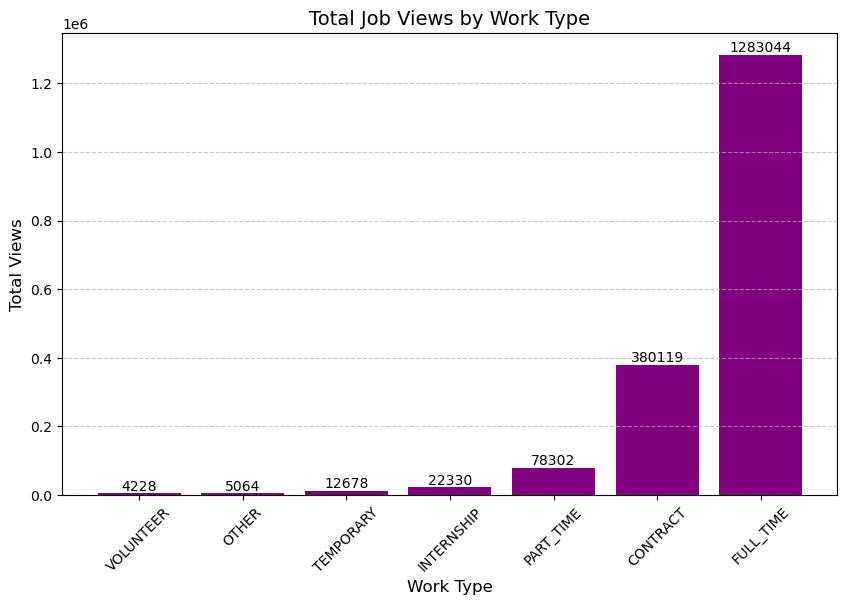

In [28]:
# Calculate total views by work type
work_type_views = merged_df2.groupby('work_type')['views'].sum().sort_values()

# Plotting the total views by work type
plt.figure(figsize=(10, 6))
bars = plt.bar(work_type_views.index, work_type_views.values, color='purple')

# Adding labels on the bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',  # Display the height as an integer
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title('Total Job Views by Work Type', fontsize=14)
plt.xlabel('Work Type', fontsize=12)
plt.ylabel('Total Views', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


The bar chart shows that total job views vary significantly across different work types. Full-time positions dominate due to their large number, but contract roles also attract very high engagement despite fewer postings indicating strong demand. Part-time and internship roles receive moderate interest, while temporary, volunteer, and smaller roles attract the least attention. This demonstrates that work type is an influential factor in job visibility and should be included in the analysis for explaining variations in job views. These suggest that job seekers may prefer long term positions, especially those that serve as their main source of income. They might be less interested in roles that do not offer salaries, such as volunteer opportunities, or jobs that don't provide stability for the future.

#### 2. How do job views differ across experience levels, and which experience level attracts the highest engagement?

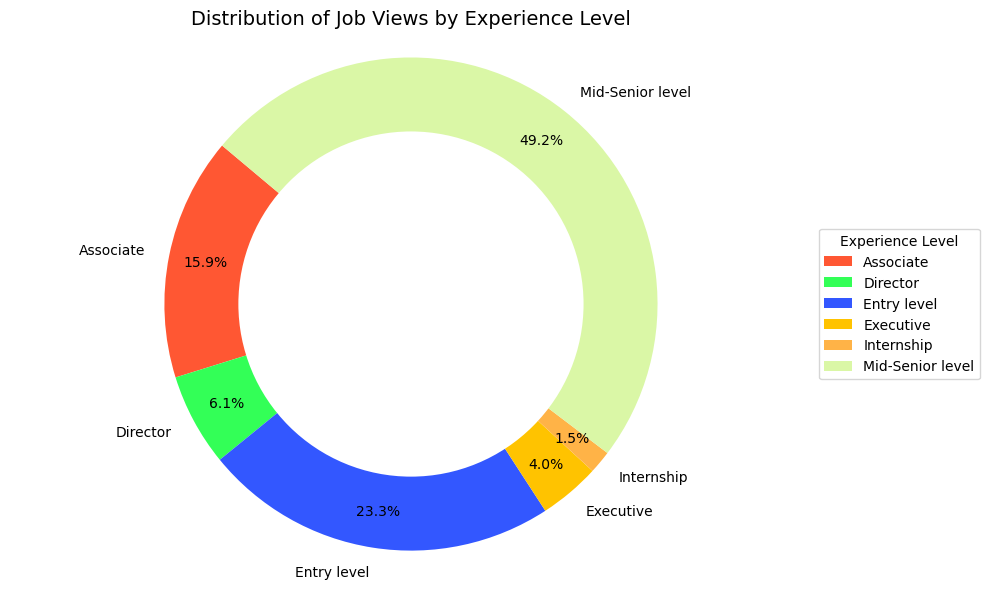

In [29]:
# Ensure 'unknown' is removed
exp_df = merged_df2[merged_df2['formatted_experience_level'].str.strip().str.lower() != 'unknown']

# Calculate the total views per experience level
views_per_level = exp_df.groupby('formatted_experience_level')['views'].sum()

custom_colors = ['#FF5733', '#33FF57', '#3357FF', '#FFC300', '#FFB347', '#DAF7A6', '#581845']


# Plot the pie chart
plt.figure(figsize=(10, 6))
wedges, texts, autotexts = plt.pie(views_per_level, labels=views_per_level.index, autopct='%1.1f%%', colors=custom_colors, startangle=140, pctdistance=0.85)

# Customize the legend to avoid overlapping
plt.legend(wedges, views_per_level.index, title="Experience Level", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Add a circle at the center to make it look like a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Ensure the pie is drawn as a circle
plt.axis('equal')

# Customize the plot title and layout
plt.title('Distribution of Job Views by Experience Level', fontsize=14)
plt.tight_layout()
plt.show()

The donut chart reveals that mid-senior and entry-level roles receive the majority of job views, making experience level a strong influencing factor in job visibility. Roles requiring  seniority eg. Director, Executive attract significantly fewer views, while internships receive the least attention. This indicates that job seekers mostly engage with mid-career and junior positions, highlighting experience level as an important predictor of job view patterns.

#### 3. What does the overall distribution of job views look like, and how does log transformation help reveal underlying patterns?

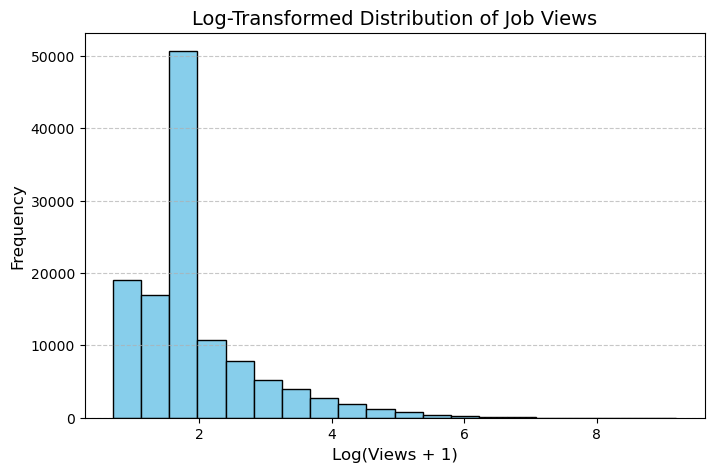

In [30]:
# Apply log transformation to the 'views' column
log_views = np.log1p(merged_df2['views'])  # log1p ensures log(0) is handled as log(1) = 0

plt.figure(figsize=(8, 5))
plt.hist(log_views, bins=20, color='skyblue', edgecolor='black')
plt.title('Log-Transformed Distribution of Job Views', fontsize=14)
plt.xlabel('Log(Views + 1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


The histogram indicates that job views are mostly right-skewed. Most postings get fewer than 10 views, while a small number receive thousands. A log transformation helps compress extreme values and creates a more balanced distribution. A possible reason for this could be that there are over 120,000 listings. A large dataset means there is a lower chance of a selected job getting many views. This makes it easier to spot patterns and connections between job visibility and other factors. This step is crucial for proper statistical analysis and directly supports the exploration of what influences job views.

#### 4.How do job views vary across different major locations, and which locations attract higher or lower engagement?

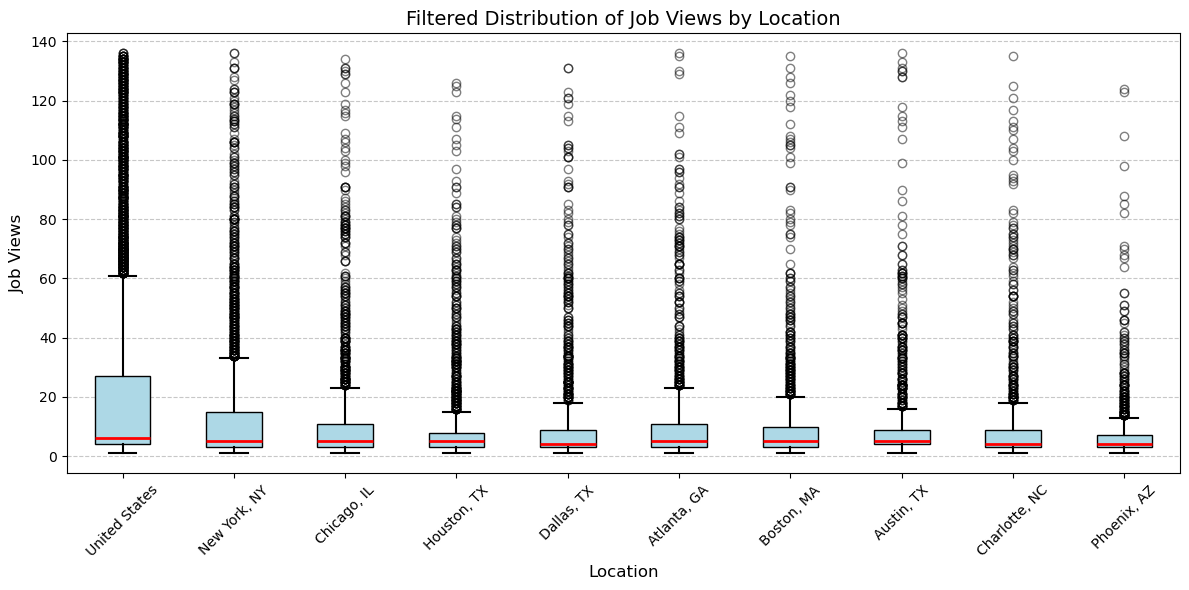

In [33]:
from matplotlib.ticker import MaxNLocator

# top 10 locations
top_locations = merged_df2['location'].value_counts().head(10).index
filtered_df = merged_df2[merged_df2['location'].isin(top_locations)]

# Define a threshold of 95th percentile
threshold = filtered_df['views'].quantile(0.95)
filtered_df = filtered_df[filtered_df['views'] <= threshold]

# Create a list of views for each location after filtering outliers
views_per_location = [filtered_df[filtered_df['location'] == loc]['views'].values for loc in top_locations]

# Plot the boxplot
plt.figure(figsize=(12, 6))
box = plt.boxplot(views_per_location, patch_artist=True, boxprops=dict(facecolor='lightblue'))

# Customize box plot
for whisker in box['whiskers']:
    whisker.set(color='black', linewidth=1.5)
for cap in box['caps']:
    cap.set(color='black', linewidth=1.5)
for median in box['medians']:
    median.set(color='red', linewidth=2)
for flier in box['fliers']:
    flier.set(marker='o', color='red', alpha=0.5)

plt.title('Filtered Distribution of Job Views by Location', fontsize=14)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Job Views', fontsize=12)
plt.xticks(range(1, len(top_locations) + 1), top_locations, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()

plt.show()

This plot removes views above the 95th percentile to limit the data range. This helps with analysis because outliers can shrink the boxes due to large variations in job views across different locations. 
We used a box plot because it displays five key statistics: the 25th percentile, 50th percentile, 75th percentile, and the smallest and largest counts of job views. It also shows skewness through the length of the top whisker compared to the bottom, along with the outliers. We can then compare the average job views across various locations.

The distribution of job views varies significantly across locations. The “United States” category has the highest overall engagement, the widest range of job views, and the largest number of extreme outliers. This indicates that broadly targeted or remote postings get much more attention than city-specific roles. In contrast, cities like New York, Chicago, Houston, Dallas, and Boston show more stable and compact distributions. In these places, typical job views are more consistent and show less variation.

We can clearly see that location has a significant impact on job views. Certain cities, like New York, attract more views for their job listings. This shows that where a job is located plays a key role in drawing interest.Major cities like New York not only have more views on average but also display a wide range of job views, including some very high numbers. This suggests that these cities may have better jobs or jobs that naturally attract greater attention.The differences in job views across various locations further emphasize the connection between location and job popularity. This supports the idea that other factors, such as salary and job titles, also influence job views since they can affect a job's appeal.

Take note: Including "United States" in this analysis would distort the insights. It combines data from all cities and regions, leading to a broader and less specific distribution. Therefore, it has the most outliers

#### 5. How does median yearly salary relate to the average number of job views?

Object `views` not found.
Pearson correlation: 0.005736192605264419
P-value: 0.04497637963875815


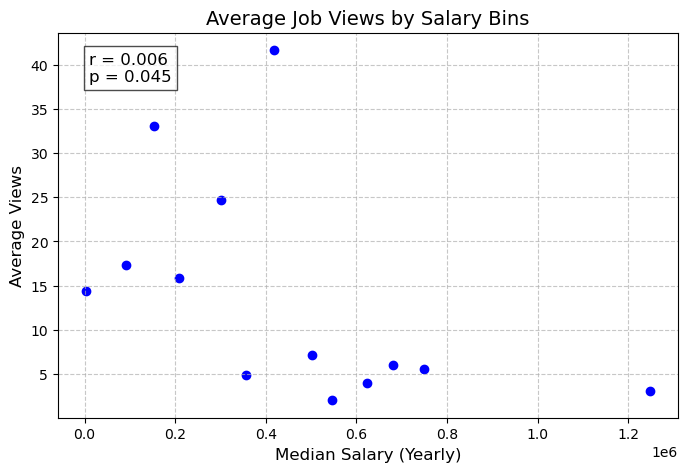

In [34]:
5. How does median yearly salary relate to the average number of job views?

from scipy.stats import pearsonr

# 1. Create salary bins
bins = np.linspace(merged_df2['med_salary_yearly'].min(),
                   merged_df2['med_salary_yearly'].max(),
                   20)

merged_df2.loc[:, 'salary_bin'] = np.digitize(merged_df2['med_salary_yearly'], bins)

# 2. Compute mean views & salary for each bin
binned_data = merged_df2.groupby('salary_bin').agg({
    'views': 'mean',
    'med_salary_yearly': 'mean'
}).reset_index()

# 3. Compute Pearson r-value & p-value
r_value, p_value = pearsonr(merged_df2['med_salary_yearly'], merged_df2['views'])
print("Pearson correlation:", r_value)
print("P-value:", p_value)

# 4. Plot scatter with correlation text
plt.figure(figsize=(8, 5))
plt.scatter(binned_data['med_salary_yearly'],
            binned_data['views'],
            color='blue')

plt.title('Average Job Views by Salary Bins', fontsize=14)
plt.xlabel('Median Salary (Yearly)', fontsize=12)
plt.ylabel('Average Views', fontsize=12)
plt.grid(linestyle='--', alpha=0.7)

# Add correlation results on chart
plt.text(0.05, 0.95,
         f"r = {r_value:.3f}\np = {p_value:.3f}",
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.show()


 Why bins and why use average job views:
1. Binning helps simplify and summarize data. It makes it easier to spot patterns and gather insights, especially when working with large datasets or Binning reduces noise and makes patterns clearer. Salary data has many unique values, which can create a scattered, noisy plot. Grouping salaries into bins smooths the data and makes trends easier to interpret.

2. Averaging job views within each bin highlights the real relationship. Individual postings can vary due to random factors, such as company brand, posting time, and keywords. Using averaged views stabilizes these random spikes and reveals the underlying salary-view trend more clearly.

The scatterplot shows how the average number of job views changes with different salary ranges based on yearly median salaries.
1. Mid-range salaries attract the most job views. 
Positions with salaries between $100k and $400k a year consistently get the highest average views, often exceeding 40 per posting. This shows that job seekers are most engaged with stable, mid-level roles ,competitive but not extreme salaries , positions that balance skill requirements and accessibility. These roles likely represent the “sweet spot” where many applicants feel qualified.

2. Extremely high salaries result in very low engagement. 
Once the median yearly salary exceeds $500k, average views drop sharply below 10, with some bins falling to 2 or 3 views. This suggests that extremely high-paying jobs tend to require rare or specialized expertise, target a much smaller specifc groups of people, seem intimidating or inaccessible to most job seekers. Thus, a high salary does not guarantee high visibility.

3. Very low salaries also receive low engagement. 
Bins under $50k show modest average views around 14 to 17, indicating that low-wage roles attract fewer serious applicants. Candidates may see these jobs as less desirable and prefer higher pay.This reflects job market behavior where applicants avoid both extremes.

4. The overall pattern is not linear it is curved
both extremely low and extremely high salaries receive fewer views, while mid-range salaries receive the most. This produces a curve-shaped relationship where engagement peaks in the middle range.

This can be supported by:
The computed Pearson correlation shows
- r = 0.006 → essentially no linear correlation 
- p = 0.045 → statistically significant but extremely weak relationship 
Salary does influence job views, but not in a simple linear way. Instead of “higher salary leads to more views,” the relationship depends on the salary range, not the raw number. 
The weak r-value is expected because the true relationship is non-linear—a bell curve, not a straight line.

In summary:
The graph shows that salary affects job views only up to a point. Job visibility peaks for mid-range salaries around $100k to $400k a year, while very low and extremely high salaries receive the fewest views. The near-zero r-value confirms that the relationship is non-linear, meaning salary alone does not strongly predict job views. This suggests that other factors, such as job title, location, and work type, likely play a larger role in driving engagement. Salary should be evaluated alongside these variables when determining what influences job visibility most.


#### 6. How is the distribution of average yearly salary different across various work types?

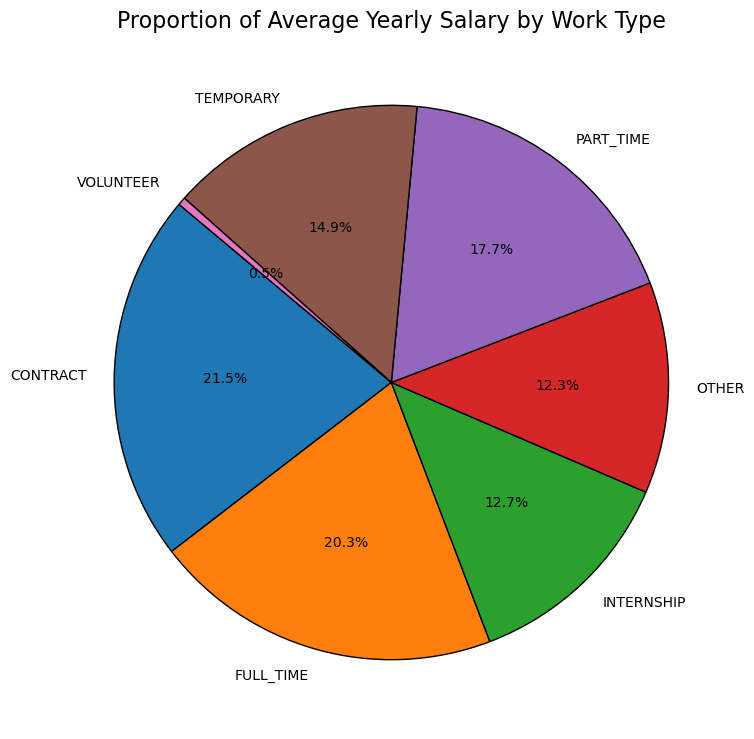

In [35]:
# average yearly salary per work type
avg_salary_by_work = merged_df2.groupby('work_type')['med_salary_yearly'].mean()

# Create a pie chart
plt.figure(figsize=(9, 9))
plt.pie(
    avg_salary_by_work,
    labels=avg_salary_by_work.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'black'},
)

plt.title("Proportion of Average Yearly Salary by Work Type", fontsize=16)
plt.show()


The pie chart shows how average yearly salaries vary among different job types. It highlights clear differences in pay that support the idea that salary affects job views. Contract roles make up the largest portion at 21.5% because they offer the highest average pay. Full-time jobs follow closely at 20.3%, also providing strong and stable salaries. Part-time and temporary roles account for moderate slices of the chart at 17.7% and 14.9%, reflecting lower pay but high job availability. Internships and “other” categories each represent about 12% to 13%, which aligns with lower but still significant average pay due to a large number of listings. Volunteer roles occupy a small 0.3% since these are unpaid and correctly assigned a salary of zero. Overall, this visual emphasizes how salary varies across job types and supports your research question by linking pay patterns to job categories. This provides context for later evaluating whether higher-salary jobs attract more views or if other factors like job title and location play a bigger role.The pie chart shows how average yearly salaries vary among different job types. It highlights clear differences in pay that support the idea that salary affects job views. Contract roles make up the largest portion at 21.5% because they offer the highest average pay. Full-time jobs follow closely at 20.3%, also providing strong and stable salaries. Part-time and temporary roles account for moderate slices of the chart at 17.7% and 14.9%, reflecting lower pay but high job availability. Internships and “other” categories each represent about 12% to 13%, which aligns with lower but still significant average pay due to a large number of listings. Volunteer roles occupy a small 0.3% since these are unpaid and correctly assigned a salary of zero. Overall, this visual emphasizes how salary varies across job types and supports your research question by linking pay patterns to job categories. This provides context for later evaluating whether higher-salary jobs attract more views or if other factors like job title and location play a bigger role.

#### 7. How are different work types distributed across major job locations, and how might this influence the number of job views?

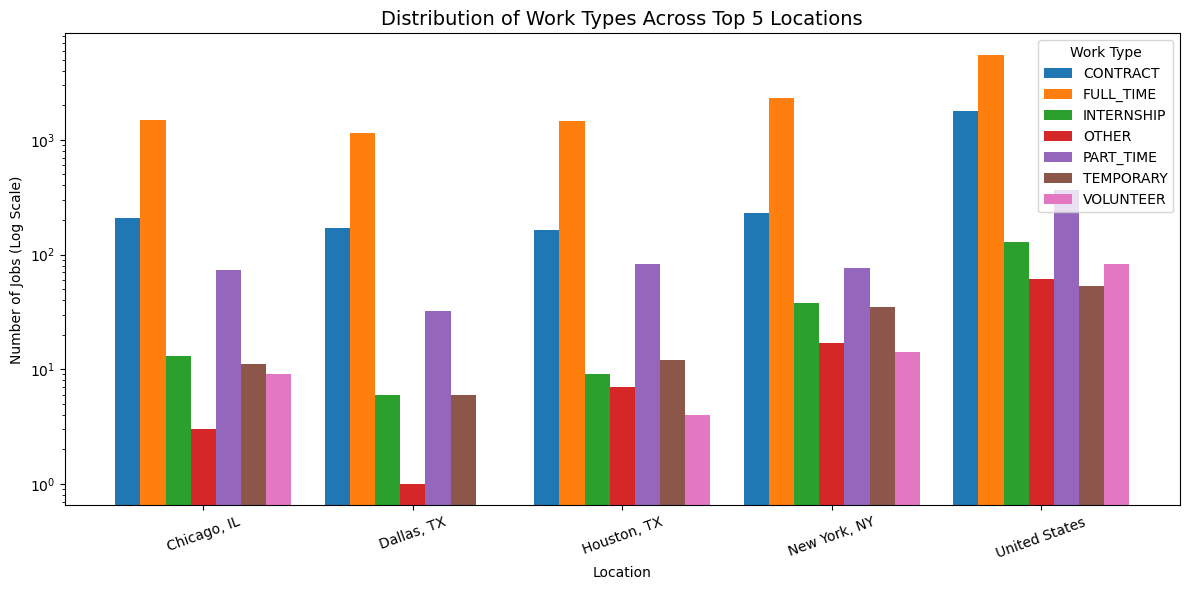

In [36]:
# top 5 locations by job count
top_5_locations = merged_df2['location'].value_counts().head(5).index

# Filter to only those 5 locations
filtered_df = merged_df2[merged_df2['location'].isin(top_5_locations)].copy()

# Create pivot table: rows = location, columns = work type
work_type_location = filtered_df.pivot_table(
    index='location',
    columns='work_type',
    values='job_id',
    aggfunc='count',
    fill_value=0
)

# Plot grouped bar chart (like your nice earlier one)
plt.figure(figsize=(12, 6))

x = np.arange(len(work_type_location.index))
width = 0.12

for i, wt in enumerate(work_type_location.columns):
    plt.bar(x + i * width,
            work_type_location[wt],
            width=width,
            label=wt)

plt.yscale('log')  # keep log scale
plt.title("Distribution of Work Types Across Top 5 Locations", fontsize=14)
plt.xlabel("Location")
plt.ylabel("Number of Jobs (Log Scale)")
plt.xticks(x + width * (len(work_type_location.columns) / 2 - 0.5),
           work_type_location.index,
           rotation=20)

plt.legend(title="Work Type")
plt.tight_layout()
plt.show()


The grouped bar chart displays the distribution of work types across the top five locations: Chicago, Dallas, Houston, New York, and United States. It features a logarithmic y-axis. I created this graph to examine the relationship between work type and location, as both are key to my research question about which factors affect job views. I used a log scale for counts so we can see both large categories, like FULL_TIME, and smaller ones, like VOLUNTEER, on the same chart without the smaller bars vanishing.

In all five locations, FULL_TIME roles clearly lead, with job counts in the thousands. CONTRACT positions follow as the second largest group. PART_TIME jobs are available in all locations, but in much lower amounts. INTERNSHIP, TEMPORARY, OTHER, and VOLUNTEER roles appear much less often and usually number in the tens or low hundreds. The “United States” category has the highest counts for every work type, showing that a large part of the dataset consists of postings labeled at a broad national level rather than a specific city.

This pattern is crucial for understanding my earlier view-based graphs. Since full-time jobs are the most prevalent work type in every major city, their high total number of views comes not only from user interest but also from the greater number of full-time postings. In contrast, categories like internships and volunteer roles start with fewer postings, which partly explains their lower total view counts. Overall, this graph backs up the idea that work type and location interact: major US cities are mainly filled with full-time and contract roles, and this job type distribution helps shape the viewing patterns seen in the rest of the analysis.

#### 8. How do salary levels and the number of available job postings influence the average number of job views?

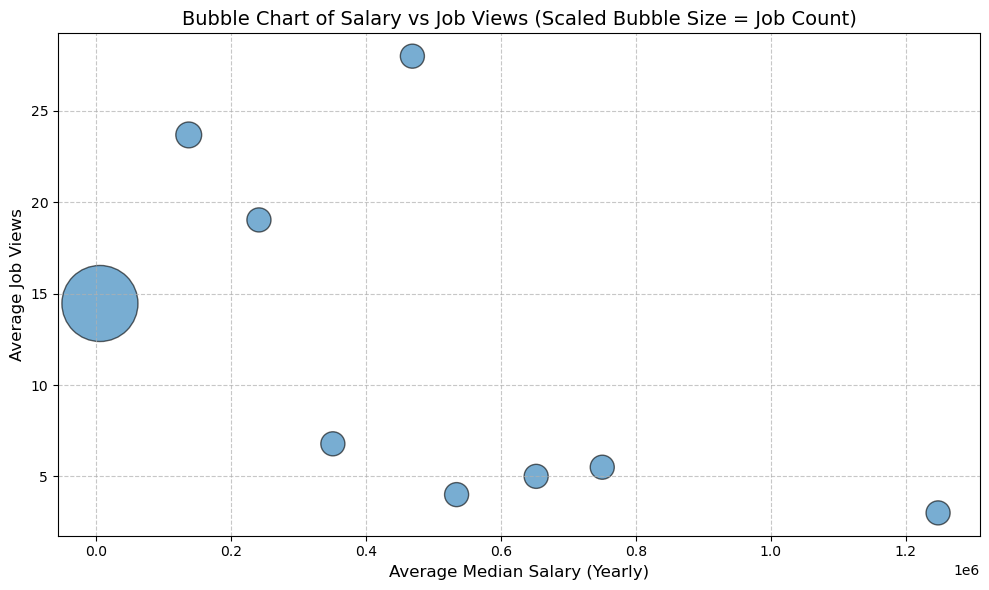

In [37]:
# Create salary bins
num_bins = 12
bins = np.linspace(merged_df2['med_salary_yearly'].min(),
                   merged_df2['med_salary_yearly'].max(),
                   num_bins + 1)

merged_df2['salary_bin'] = np.digitize(merged_df2['med_salary_yearly'], bins)

# Aggregate
bubble_data = (
    merged_df2
    .groupby('salary_bin')
    .agg(
        avg_views=('views', 'mean'),
        avg_salary=('med_salary_yearly', 'mean'),
        job_count=('job_id', 'count')
    )
    .reset_index()
)

# Remove empty rows
bubble_data = bubble_data.dropna()

# make bubbles clearer
# Normalize sizes between 300 and 3000
min_size = 300
max_size = 3000
sizes = bubble_data['job_count']

sizes_norm = min_size + (sizes - sizes.min()) / (sizes.max() - sizes.min()) * (max_size - min_size)

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    bubble_data['avg_salary'],
    bubble_data['avg_views'],
    s=sizes_norm,
    alpha=0.6,
    edgecolor='black',
    linewidth=1
)

plt.xlabel("Average Median Salary (Yearly)", fontsize=12)
plt.ylabel("Average Job Views", fontsize=12)
plt.title("Bubble Chart of Salary vs Job Views (Scaled Bubble Size = Job Count)", fontsize=14)
plt.grid(linestyle='--', alpha=0.7)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

plt.tight_layout()
plt.show()


This bubble chart shows how salary levels, average job views, and the number of available jobs are connected. Each bubble represents a salary range. The x-axis displays the average median yearly salary, the y-axis shows the average number of job views, and the size of the bubble indicates the number of job postings in that range.

The chart reveals a clear pattern:

Lower-salary jobs often get the most job views. For instance, the lowest salary range (around $0 to $50k yearly) has the largest bubble, indicating it has the most jobs, with an average of 14 to 15 views. This makes it one of the most viewed categories.

Mid-salary ranges ($100k to $400k) draw even higher average views, peaking at 23 to 28 views. This suggests that people are very interested in these mid-paying roles.

High-salary jobs ($700k to $1.2M+) receive much lower average views (3 to 6 views), even though they offer high pay. Their bubbles are also much smaller, showing there are significantly fewer jobs at these salary levels.

Overall, the graph supports the research question by demonstrating that salary influences job views, though not in a straightforward way. Job seekers generally show the most interest in low to mid-level salary ranges, likely reflecting job availability and access. High-salary positions attract fewer views, possibly due to stricter requirements and limited openings.

### 9. How are job titles distributed across different experience levels, and which positions attract higher-level or lower-level candidates?

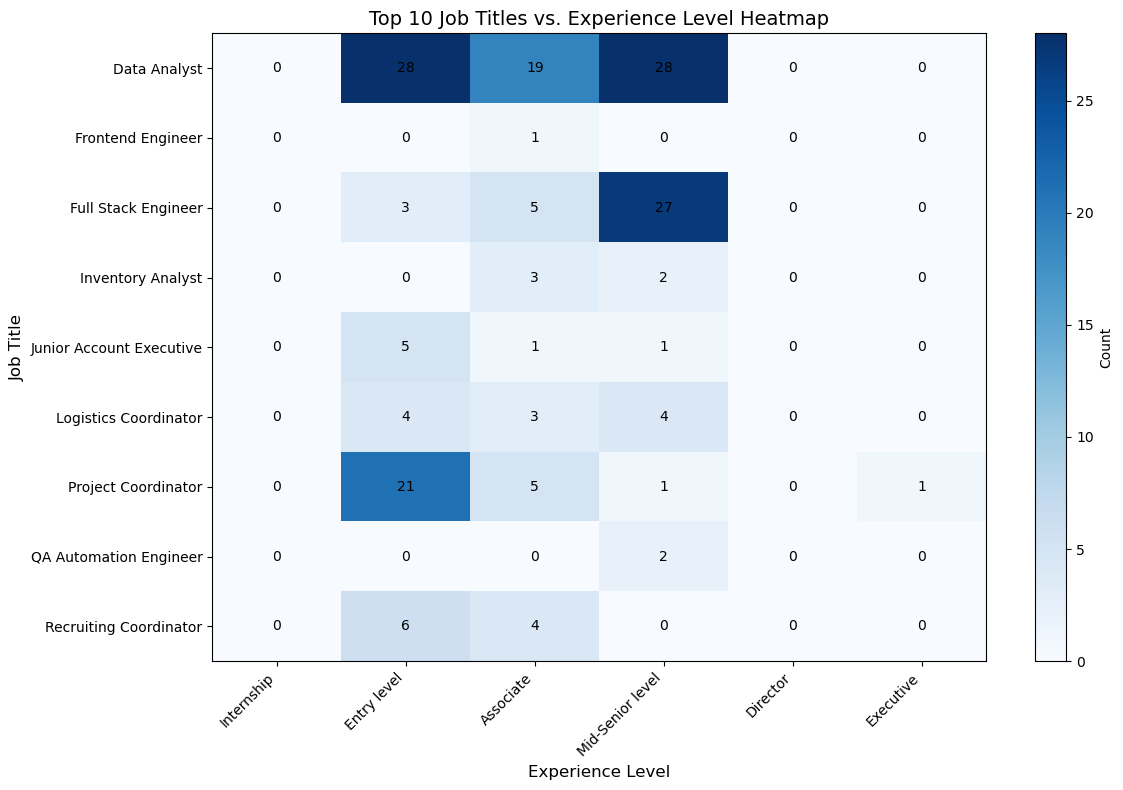

In [38]:
top_titles = [
    'Junior Account Executive', 'Executive Operation Manager', 'Inventory Analyst', 'Data Analyst',
    'Full Stack Engineer', 'Recruiting Coordinator', 'Logistics Coordinator', 'Frontend Engineer',
    'QA Automation Engineer', 'Project Coordinator'
]

experience_levels = ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']

# Filter the dataframe for the top 10 job titles and non-unknown experience levels
exp_df = merged_df2[merged_df2['formatted_experience_level'].str.strip().str.lower() != 'unknown']
filtered_df = exp_df[exp_df['title'].isin(top_titles)]

# Create a contingency table of counts for the filtered dataframe
title_experience_counts = pd.crosstab(filtered_df['title'], filtered_df['formatted_experience_level'])

# Reindex the contingency table to include all experience levels
title_experience_counts = title_experience_counts.reindex(columns=experience_levels, fill_value=0)

# Plot the heatmap
plt.figure(figsize=(12, 8))
plt.imshow(title_experience_counts, cmap='Blues', aspect='auto')

# Add color bar
plt.colorbar(label='Count')

# Set the labels
plt.xticks(range(len(title_experience_counts.columns)), title_experience_counts.columns, rotation=45, ha='right')
plt.yticks(range(len(title_experience_counts.index)), title_experience_counts.index)
plt.title('Top 10 Job Titles vs. Experience Level Heatmap', fontsize=14)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Job Title', fontsize=12)

# Add text annotations
for i in range(len(title_experience_counts.index)):
    for j in range(len(title_experience_counts.columns)):
        plt.text(j, i, title_experience_counts.iat[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

The heatmap displays the distribution of the top 10 job titles across different experience levels: Internship, Entry level, Associate, Mid-Senior level, Director, and Executive. Darker cells represent a higher number of postings for each title-experience combination. Most of these sought-after roles are found at Entry level, Associate, and Mid-Senior level, while there are very few postings at the Director or Executive level for these titles.

For instance, Data Analyst is common across three levels 28 at Entry, 19 at Associate, and 28 at Mid-Senior, suggesting it is a versatile role suitable for both newcomers and those with more experience. Full Stack Engineer leans heavily toward Mid-Senior level 27 postings, showing that employers often prefer more experienced candidates for this position. In contrast, roles like Project Coordinator and Junior Account Executive are primarily at the Entry level 21 and 5 postings, respectively, indicating they are typical entry positions. Some titles, such as Inventory Analyst, Logistics Coordinator, and Recruiting Coordinator, fall between Associate and Mid-Senior but still mostly remain in the lower levels.

In relation to my research question, this heatmap indicates a close connection between job title and experience level. Popular titles like Data Analyst and Project Coordinator are readily available at junior levels, potentially attracting more views since more early-career job seekers can apply. Conversely, titles like Full Stack Engineer are more prominent at mid-senior level, targeting a smaller, specialized audience and likely receiving fewer views per posting. This reinforces the idea that both job title and required experience influence how appealing and visible a posting is to job seekers.

# CONCLUSION:
In conclusion, this analysis aimed to explore which factors, including salary, job title, work type, and location, have the most significant impact on job views. Through careful data cleaning, analysis, and visualization, the findings consistently indicate that no single variable determines job views on its own. Instead, job engagement seems to depend on a mix of role-specific expectations, market demand, and worker preferences, with each factor playing a different role based on the context.

Salary showed a moderate but not dominant influence. Higher salary often attracted more views, but this effect was inconsistent across job titles. This suggests that pay is important, but only when it matches individual role and required skills. Job titles revealed clearer trends. Popular fields like Data Analyst, Full Stack Engineer, and Software Engineer consistently drew the most interest, reflecting solid demand in the tech sector. The distribution of work types across locations showed that cities with more hybrid and on-site roles had higher viewership, likely due to greater job availability or employer presence.

Location also had a significant impact, especially when viewed through bubble plots and distribution charts. Areas with high population density or economic activity generated more job views, supporting the idea that geographical hubs have more appeal for job seekers. However, this effect varied depending on whether the job type was remote-friendly. This suggests location interacts with work type and job title, rather than affecting views on its own.

Overall, the analysis reveals that job views are shaped by a combination of salary, job title, work type, and location, with job title being the strongest and most consistent factor. 

RANKING:
1. Job Title (biggest influence)
2. Salary (moderate influence, depending on job title)
3. Location (some influence but inconsistent)
4. Work Type (smallest effect overall)